In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports Libraries and Tools

In [ ]:
import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement
from tensorflow.keras.preprocessing.image import load_img  # For loading images
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import VGG16  # For using VGG16 model
from sklearn.utils import shuffle  # For shuffling the data

In [ ]:
# Load Datasets

In [ ]:
# Directories for training and testing data
train_dir = '/content/drive/MyDrive/streamlit data/Training'
test_dir = '/content/drive/MyDrive/streamlit data/Testing'

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

In [ ]:
# Data Visualization

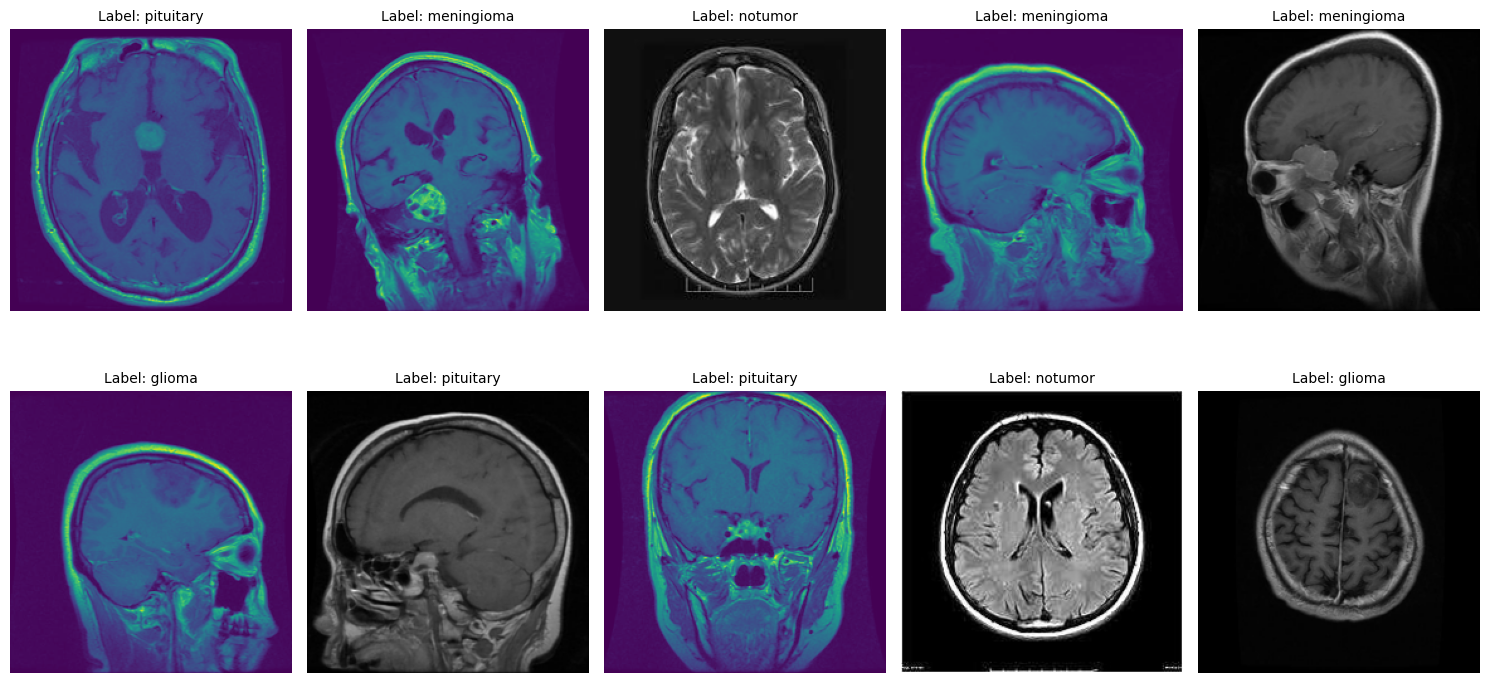

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Image Preprocessing (Helper Functions)

In [ ]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
        # Random flips
    if random.random() > 0.5:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)

    # Rotation
    image = image.rotate(random.randint(-15, 15))


    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.7, 1.3))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.7, 1.3))  # Random contrast
    return np.array(image) / 255.0  # Normalize pixel values to [0, 1]


# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
  class_names = ['pituitary', 'glioma', 'notumor', 'meningioma']

def encode_label(labels):
    return np.array([class_names.index(label) for label in labels])

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

In [ ]:
MODEL:
# WE ARE USING VGG16 FOR TRANSFER LEARNING.

In [ ]:
# ==============================
# DEFINE CLASS NAMES (FIX)
# ==============================
class_names = ['pituitary', 'glioma', 'notumor', 'meningioma']

# ==============================
# MODEL ARCHITECTURE
# ==============================
IMAGE_SIZE = 224

base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last 10 layers
for layer in base_model.layers[-10:]:
    layer.trainable = True

# ==============================
# BUILD MODEL
# ==============================
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

# FIX: use len(class_names) instead of os.listdir
model.add(Dense(len(class_names), activation='softmax'))

# ==============================
# COMPILE
# ==============================
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

# ==============================
# TRAINING PARAMS
# ==============================
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 15

# ==============================
# TRAIN MODEL
# ==============================
history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 1592s 6s/step - loss: 0.5553 - sparse_categorical_accuracy: 0.7907
Epoch 2/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 66s 236ms/step - loss: 0.2679 - sparse_categorical_accuracy: 0.9004
Epoch 3/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 66s 235ms/step - loss: 0.2106 - sparse_categorical_accuracy: 0.9250
Epoch 4/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 65s 233ms/step - loss: 0.1566 - sparse_categorical_accuracy: 0.9429
Epoch 5/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 65s 231ms/step - loss: 0.1258 - sparse_categorical_accuracy: 0.9541
Epoch 6/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 65s 233ms/step - loss: 0.0843 - sparse_categorical_accuracy: 0.9707
Epoch 7/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 65s 231ms/step - loss: 0.0934 - sparse_categorical_accuracy: 0.9657
Epoch 8/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 65s 232ms/step - loss: 0.0878 - sparse_categorical_accuracy: 0.9704
Epoch 9/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 65s 233ms/step - loss: 0.0783 - sparse_categor

In [ ]:
# Train and Val Plots

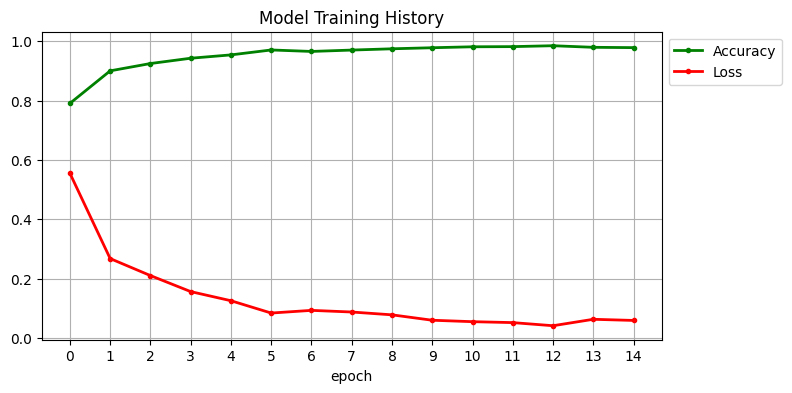

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [ ]:
# Model Classification Report

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 198ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       400
           1       0.98      0.79      0.87       400
           2       0.95      0.98      0.97       400
           3       0.85      0.97      0.91       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



In [ ]:
# Model Confusion Plot

Confusion Matrix:
[[391   0   0   9]
 [  6 317  19  58]
 [  0   4 394   2]
 [  4   4   2 390]]


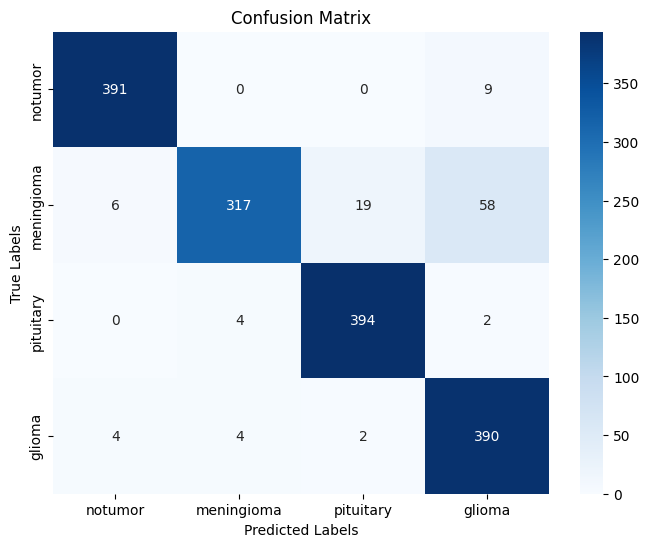

In [ ]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
# Roc Curve Plot

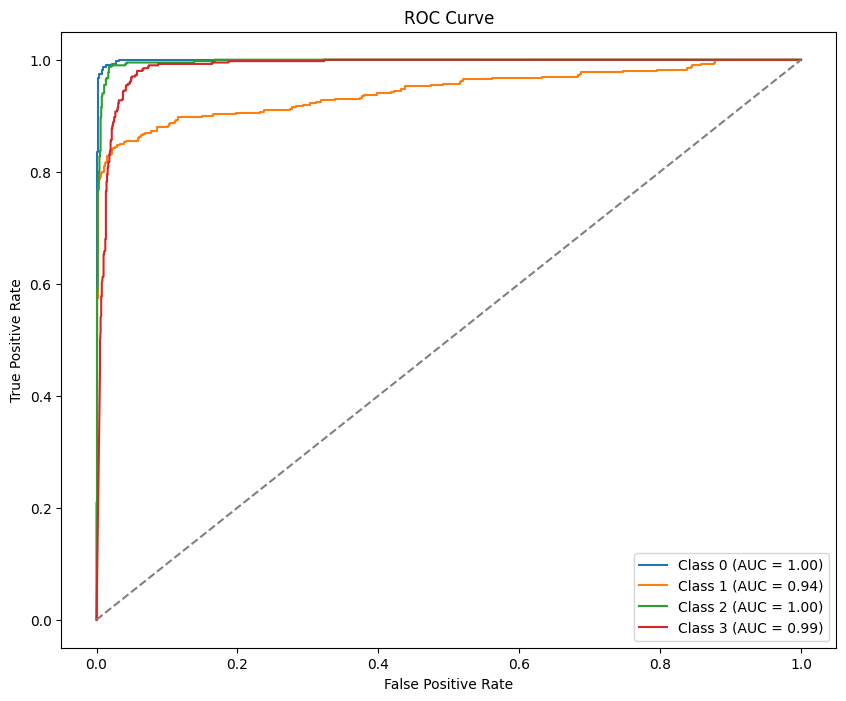

In [ ]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Save & Load Model

In [ ]:
# Save the entire model
model.save('model.h5')

In [ ]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.h5')

In [ ]:
# MRI Tumor Detection System

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))